 Proyecto Final – Predicción del rendimiento académico

Objetivo predecir si un estudiante aprueba o desaprueba usando datos académicos.

Dataset: Student Performance Dataset 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Result.csv")
df.head()

,Student_ID,Gender,Study_Hours,Attendance,Math_Score,Science_Score,Sleep_Hours,Internet_Usage_Hours,Final_Result
0,1,M,3.40,57,58,50.0,4.90,6,Pass
1,2,F,3.04,98,88,93.0,6.91,2,Pass
2,3,M,4.10,64,76,65.0,6.10,5,Pass
3,4,M,2.30,66,46,91.0,6.80,7,Pass
4,5,M,3.04,72,51,71.0,6.80,2,Pass


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   str    
 2   Study_Hours           1000 non-null   float64
 3   Attendance            1000 non-null   int64  
 4   Math_Score            1000 non-null   int64  
 5   Science_Score         1000 non-null   float64
 6   Sleep_Hours           1000 non-null   float64
 7   Internet_Usage_Hours  1000 non-null   int64  
 8   Final_Result          1000 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 70.4 KB


In [6]:
df.isnull().sum()

Student_ID              0
Gender                  0
Study_Hours             0
Attendance              0
Math_Score              0
Science_Score           0
Sleep_Hours             0
Internet_Usage_Hours    0
Final_Result            0
dtype: int64

In [7]:
df.describe()

,Student_ID,Study_Hours,Attendance,Math_Score,Science_Score,Sleep_Hours,Internet_Usage_Hours
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.04665,74.904000,65.404000,65.305860,6.974910,4.986000
std,288.819436,1.13720,14.350705,20.060139,19.023065,0.956384,2.577683
min,1.000000,-0.50000,50.000000,30.000000,30.000000,4.100000,1.000000
25%,250.750000,2.30000,63.000000,48.000000,50.000000,6.400000,3.000000
50%,500.500000,3.05000,75.000000,65.000000,65.310000,6.960000,5.000000
75%,750.250000,3.70000,87.000000,83.000000,82.000000,7.600000,7.000000
max,1000.000000,6.70000,99.000000,99.000000,99.000000,9.600000,9.000000


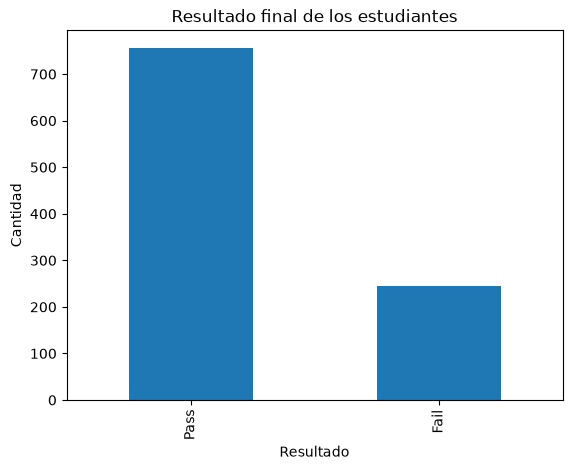

In [8]:
df["Final_Result"].value_counts().plot(kind="bar")
plt.title("Resultado final de los estudiantes")
plt.xlabel("Resultado")
plt.ylabel("Cantidad")
plt.show()

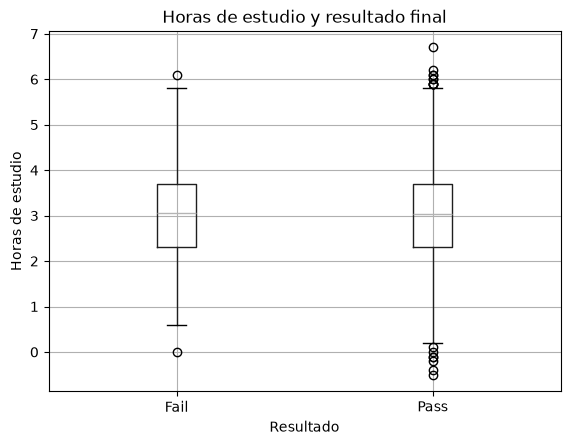

In [9]:
df.boxplot(column="Study_Hours", by="Final_Result")
plt.title("Horas de estudio y resultado final")
plt.suptitle("")
plt.xlabel("Resultado")
plt.ylabel("Horas de estudio")
plt.show()

## Preparación de los datos

Convertimos el resultado final a números: **Pass = 1** y **Fail = 0**.

In [10]:
X = df[["Study_Hours", "Attendance", "Math_Score", "Science_Score", "Sleep_Hours"]]
y = df["Final_Result"].map({"Pass": 1, "Fail": 0})

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelo 1: Regresión Logística

In [12]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [13]:
y_pred = modelo.predict(X_test)
y_pred[:10]

array([0, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy de Regresión Logística:", accuracy)

Accuracy de Regresión Logística: 0.895


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 30  21]
 [  0 149]]


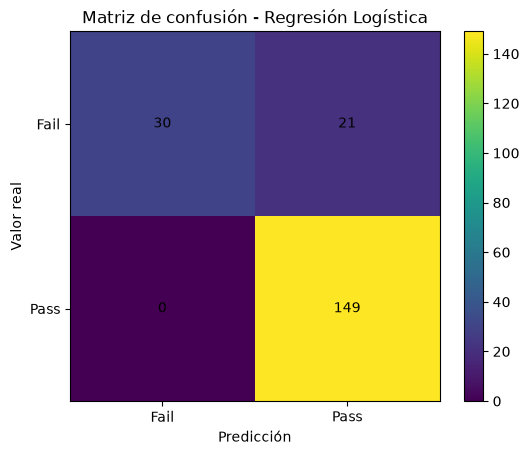

In [16]:
plt.imshow(cm)
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.colorbar()
plt.xticks([0,1], ["Fail","Pass"])
plt.yticks([0,1], ["Fail","Pass"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

## Modelo 2: Deep Learning con PyTorch

Se normalizan las variables para que la red neuronal pueda trabajar mejor con ellas.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
import torch
import torch.nn as nn

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

modelo_dl = nn.Sequential(
    nn.Linear(5, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)

print(modelo_dl)

Sequential(
  (0): Linear(in_features=5, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): Sigmoid()
)


In [19]:
criterio = nn.MSELoss()

for epoca in range(5000):
    prediccion = modelo_dl(X_train_t)
    perdida = criterio(prediccion, y_train_t)
    perdida.backward()

    with torch.no_grad():
        for parametro in modelo_dl.parameters():
            parametro -= 0.01 * parametro.grad

    modelo_dl.zero_grad()

print("Entrenamiento terminado")

Entrenamiento terminado


In [20]:
with torch.no_grad():
    pred_dl = modelo_dl(X_test_t)
    pred_dl = (pred_dl >= 0.5).int()

accuracy_dl = (pred_dl == y_test_t.int()).float().mean().item()
print("Accuracy de Deep Learning:", accuracy_dl)

Accuracy de Deep Learning: 0.8899999856948853


In [21]:
cm_dl = confusion_matrix(y_test, pred_dl.numpy().ravel())
print(cm_dl)

[[ 29  22]
 [  0 149]]


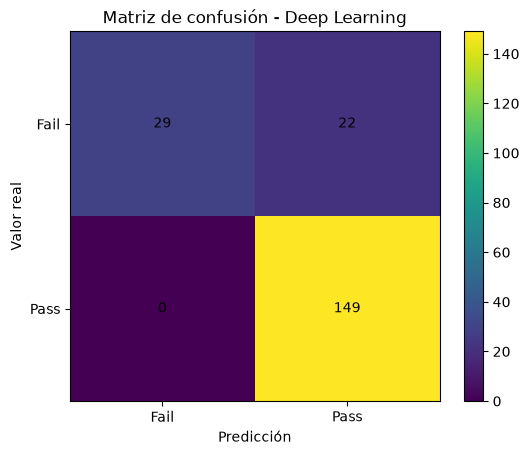

In [22]:
plt.imshow(cm_dl)
plt.title("Matriz de confusión - Deep Learning")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.colorbar()
plt.xticks([0,1], ["Fail","Pass"])
plt.yticks([0,1], ["Fail","Pass"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_dl[i,j], ha="center", va="center")
plt.show()

## Comparación de modelos

In [23]:
print("Regresión Logística:", round(accuracy, 3))
print("Deep Learning:", round(accuracy_dl, 3))

Regresión Logística: 0.895
Deep Learning: 0.89


## Conclusiones

- El modelo permite predecir el resultado final de un estudiante.
- Se utilizaron horas de estudio, asistencia y calificaciones como variables principales.
- Se comparó Regresión Logística con una red neuronal sencilla de Deep Learning.
- El modelo con mayor accuracy obtuvo el mejor resultado en esta prueba.